# Adaptive Tile Processing — Results Analysis
Visualizes all 8 experiments from `outputs/logs/experiment_results.csv`.

In [19]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
LOGS = Path('../outputs/logs')
FIGS = Path('../outputs/figures')
FIGS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(LOGS / 'experiment_results.csv')
print(f"{len(df)} rows, experiments: {sorted(df['experiment'].unique())}")
df.head()

246 rows, experiments: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']


,mode,pipeline,dataset,image_id,n_workers,tile_size,halo,scheduler,total_time_s,speedup,efficiency,imbalance_ratio,psnr,ssim,n_tiles,experiment
0,cpu_serial,denoise_threshold,kodak,kodim01,1,128,16,serial,1.111319,1.000000,1.000000,1.000000,0.0,0.0,24,A
1,cpu_parallel,denoise_threshold,kodak,kodim01,1,128,16,dynamic,7.004744,0.158652,0.158652,1.069821,inf,1.0,24,A
2,cpu_parallel,denoise_threshold,kodak,kodim01,2,128,16,dynamic,6.498907,0.171001,0.085500,1.123993,inf,1.0,24,A
3,cpu_parallel,denoise_threshold,kodak,kodim01,4,128,16,dynamic,6.699124,0.165890,0.041473,1.080266,inf,1.0,24,A
4,cpu_parallel,denoise_threshold,kodak,kodim01,8,128,16,dynamic,11.887837,0.093484,0.011685,2.078101,inf,1.0,24,A


## Experiment A — Speedup & Efficiency vs Worker Count

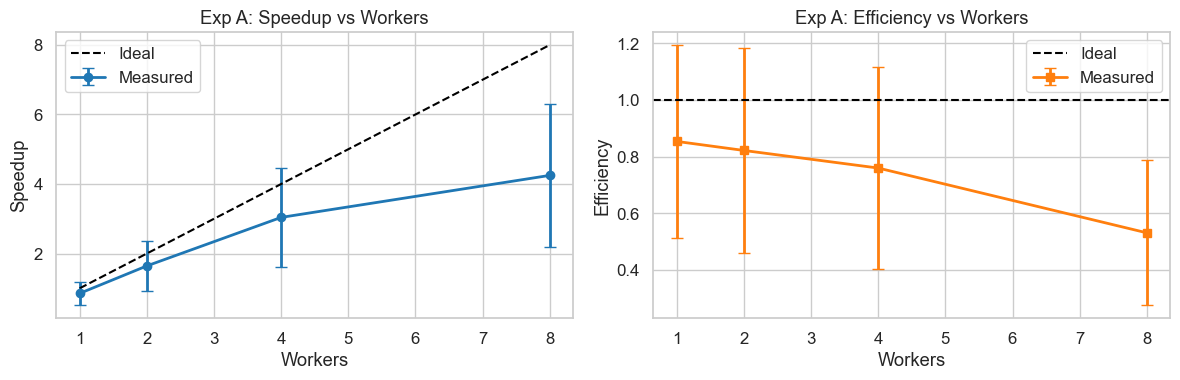

 n_workers  speedup  efficiency
         1 0.853975    0.853975
         2 1.644073    0.822036
         4 3.039635    0.759909
         8 4.248141    0.531018


In [20]:
expA = df[df['experiment'] == 'A'].copy()
par = expA[expA['mode'] == 'cpu_parallel']

mean_sp = par.groupby('n_workers')[['speedup', 'efficiency']].mean().reset_index()
std_sp  = par.groupby('n_workers')[['speedup', 'efficiency']].std().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Speedup
ax = axes[0]
ax.errorbar(mean_sp.n_workers, mean_sp.speedup, yerr=std_sp.speedup,
            marker='o', linewidth=2, capsize=4, label='Measured')
ax.plot(mean_sp.n_workers, mean_sp.n_workers, 'k--', label='Ideal')
ax.set_xlabel('Workers'); ax.set_ylabel('Speedup')
ax.set_title('Exp A: Speedup vs Workers')
ax.legend()

# Efficiency
ax = axes[1]
ax.errorbar(mean_sp.n_workers, mean_sp.efficiency, yerr=std_sp.efficiency,
            marker='s', linewidth=2, capsize=4, color='tab:orange', label='Measured')
ax.axhline(1.0, color='k', linestyle='--', label='Ideal')
ax.set_xlabel('Workers'); ax.set_ylabel('Efficiency')
ax.set_title('Exp A: Efficiency vs Workers')
ax.legend()

plt.tight_layout()
plt.savefig(FIGS / 'expA_speedup_efficiency.png', dpi=150)
plt.show()
print(mean_sp.to_string(index=False))

## Experiment B — Scheduler Comparison

C:\Users\USERAS\AppData\Local\Temp\ipykernel_2460\3086861648.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  par['scheduler'] = pd.Categorical(par['scheduler'], categories=sched_order, ordered=True)
C:\Users\USERAS\AppData\Local\Temp\ipykernel_2460\3086861648.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=par, x='scheduler', y=metric, order=sched_order, ax=ax,
C:\Users\USERAS\AppData\Local\Temp\ipykernel_2460\3086861648.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False

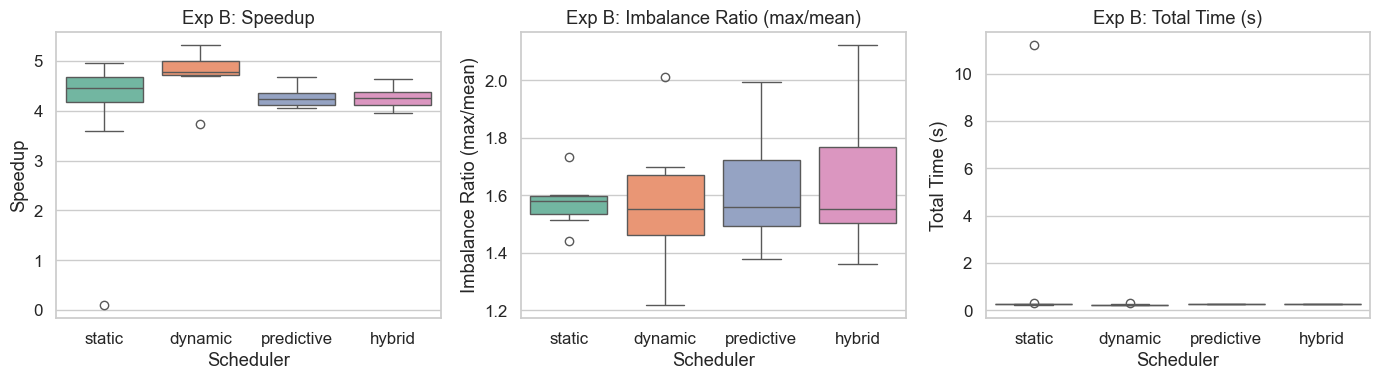

            speedup  imbalance_ratio
scheduler                           
static        3.926            1.573
dynamic       4.761            1.575
predictive    4.277            1.618
hybrid        4.272            1.641


C:\Users\USERAS\AppData\Local\Temp\ipykernel_2460\3086861648.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(par.groupby('scheduler')[['speedup','imbalance_ratio']].mean().round(3).to_string())


In [21]:
expB = df[df['experiment'] == 'B'].copy()
par = expB[expB['mode'] != 'cpu_serial']

sched_order = ['static', 'dynamic', 'predictive', 'hybrid']
par['scheduler'] = pd.Categorical(par['scheduler'], categories=sched_order, ordered=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metric, label in zip(axes,
        ['speedup', 'imbalance_ratio', 'total_time_s'],
        ['Speedup', 'Imbalance Ratio (max/mean)', 'Total Time (s)']):
    sns.boxplot(data=par, x='scheduler', y=metric, order=sched_order, ax=ax,
                palette='Set2')
    ax.set_xlabel('Scheduler'); ax.set_ylabel(label)
    ax.set_title(f'Exp B: {label}')

plt.tight_layout()
plt.savefig(FIGS / 'expB_scheduler_comparison.png', dpi=150)
plt.show()

print(par.groupby('scheduler')[['speedup','imbalance_ratio']].mean().round(3).to_string())

## Experiment C — Tile Size Study

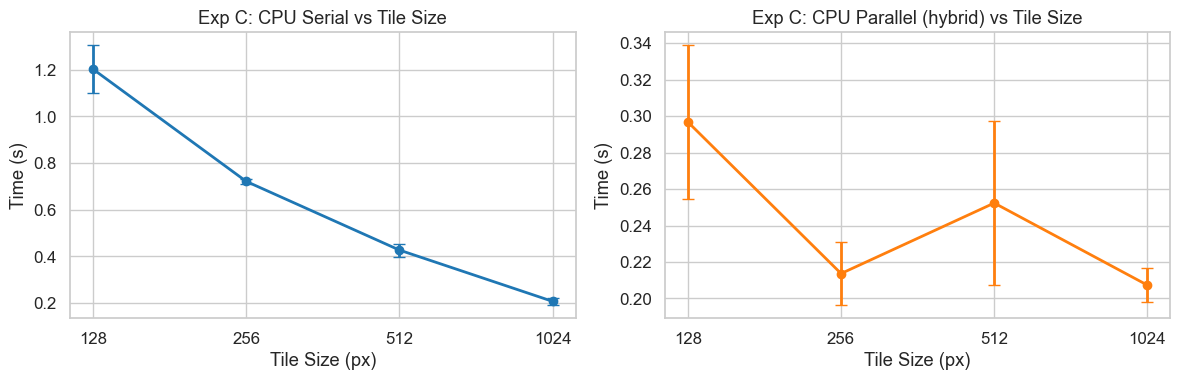

In [22]:
expC = df[df['experiment'] == 'C'].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, mode, label, color in zip(axes,
        ['cpu_serial', 'cpu_parallel'],
        ['CPU Serial', 'CPU Parallel (hybrid)'],
        ['tab:blue', 'tab:orange']):
    sub = expC[expC['mode'] == mode].groupby('tile_size')['total_time_s'].agg(['mean','std']).reset_index()
    ax.errorbar(sub.tile_size, sub['mean'], yerr=sub['std'],
                marker='o', linewidth=2, capsize=4, color=color)
    ax.set_xlabel('Tile Size (px)'); ax.set_ylabel('Time (s)')
    ax.set_title(f'Exp C: {label} vs Tile Size')
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

plt.tight_layout()
plt.savefig(FIGS / 'expC_tile_size.png', dpi=150)
plt.show()

## Experiment D — Halo Ablation (PSNR & SSIM)

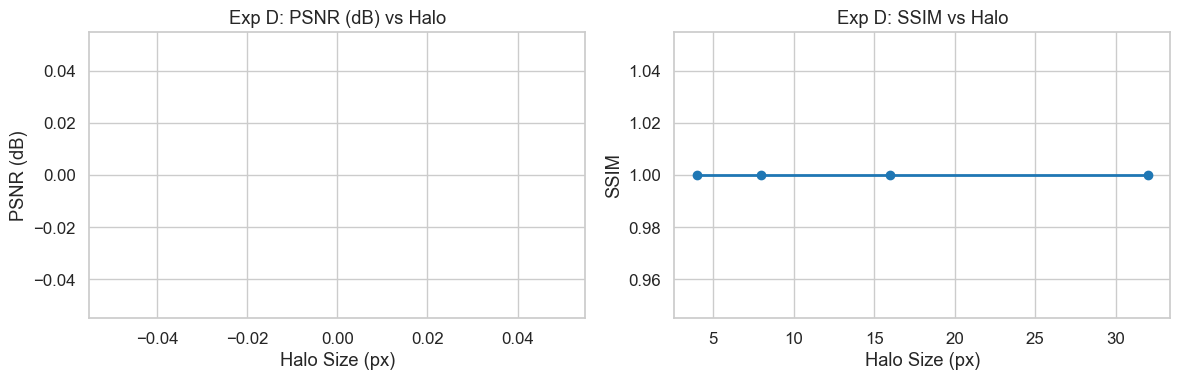

 halo  psnr  ssim
    4   inf   1.0
    8   inf   1.0
   16   inf   1.0
   32   inf   1.0


In [23]:
expD = df[df['experiment'] == 'D'].copy()
par = expD[expD['mode'] == 'cpu_parallel']

mean_d = par.groupby('halo')[['psnr','ssim']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, label in zip(axes, ['psnr','ssim'], ['PSNR (dB)','SSIM']):
    ax.plot(mean_d.halo, mean_d[metric], marker='o', linewidth=2)
    ax.set_xlabel('Halo Size (px)'); ax.set_ylabel(label)
    ax.set_title(f'Exp D: {label} vs Halo')

plt.tight_layout()
plt.savefig(FIGS / 'expD_halo_ablation.png', dpi=150)
plt.show()
print(mean_d.to_string(index=False))

## Experiment E — Pipeline A vs Pipeline B

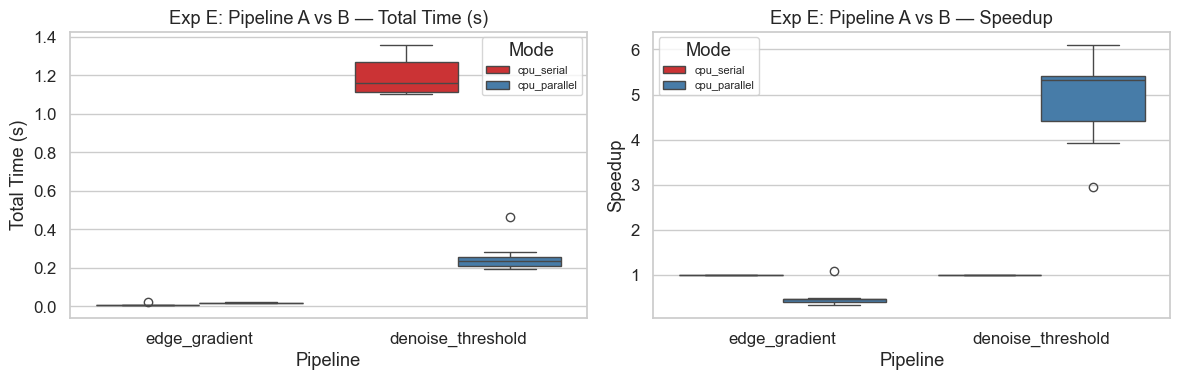

                                total_time_s  speedup
pipeline          mode                               
denoise_threshold cpu_parallel         0.259    4.883
                  cpu_serial           1.193    1.000
edge_gradient     cpu_parallel         0.016    0.508
                  cpu_serial           0.009    1.000


In [24]:
expE = df[df['experiment'] == 'E'].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, label in zip(axes, ['total_time_s','speedup'], ['Total Time (s)','Speedup']):
    sns.boxplot(data=expE, x='pipeline', y=metric, hue='mode',
                palette='Set1', ax=ax)
    ax.set_xlabel('Pipeline'); ax.set_ylabel(label)
    ax.set_title(f'Exp E: Pipeline A vs B — {label}')
    ax.legend(title='Mode', fontsize=8)

plt.tight_layout()
plt.savefig(FIGS / 'expE_pipeline_comparison.png', dpi=150)
plt.show()
print(expE.groupby(['pipeline','mode'])[['total_time_s','speedup']].mean().round(3).to_string())

## Experiment G — 4-Mode Comparison (Key Figure)

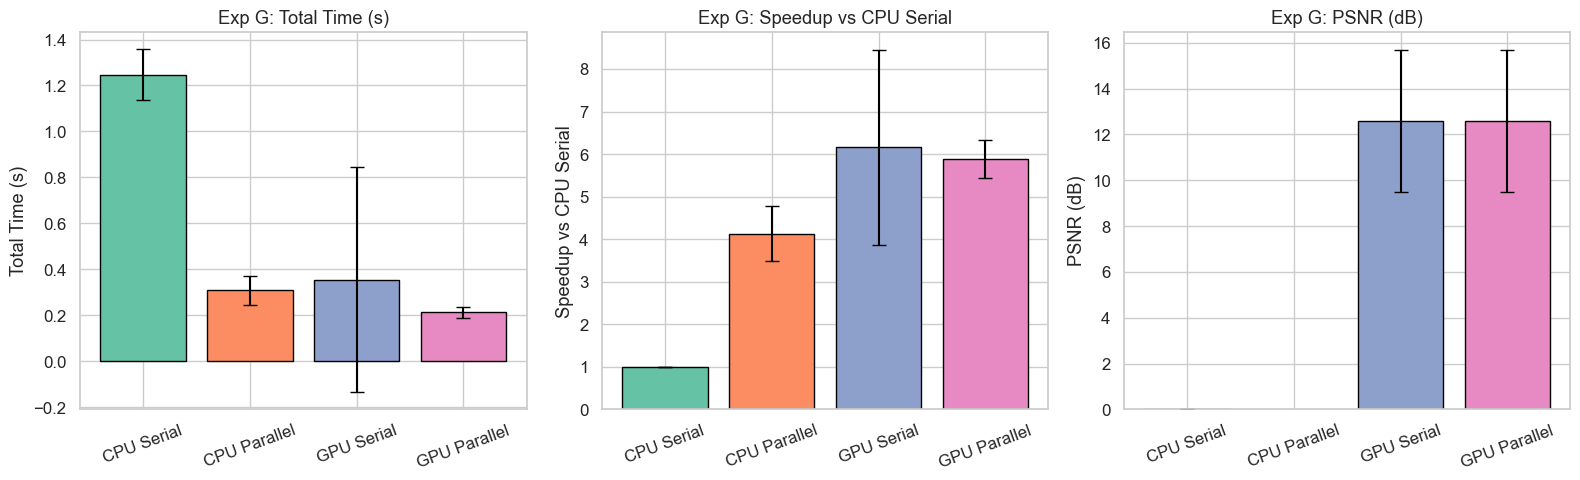

              total_time_s  speedup    psnr   ssim
mode                                              
cpu_parallel         0.310    4.132     inf  1.000
cpu_serial           1.247    1.000   0.000  0.000
gpu_parallel         0.213    5.881  12.588  0.766
gpu_serial           0.355    6.163  12.588  0.766


In [25]:
expG = df[df['experiment'] == 'G'].copy()

mode_order = [m for m in ['cpu_serial','cpu_parallel','gpu_serial','gpu_parallel']
              if m in expG['mode'].unique()]
mode_labels = {'cpu_serial':'CPU Serial','cpu_parallel':'CPU Parallel',
               'gpu_serial':'GPU Serial','gpu_parallel':'GPU Parallel'}

mean_g = expG.groupby('mode')[['total_time_s','speedup','psnr','ssim']].mean()
std_g  = expG.groupby('mode')[['total_time_s','speedup','psnr','ssim']].std()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, label in zip(axes,
        ['total_time_s','speedup','psnr'],
        ['Total Time (s)','Speedup vs CPU Serial','PSNR (dB)']):
    vals  = [mean_g.loc[m, metric] if m in mean_g.index else 0 for m in mode_order]
    errs  = [std_g.loc[m, metric]  if m in std_g.index  else 0 for m in mode_order]
    colors = sns.color_palette('Set2', len(mode_order))
    bars = ax.bar([mode_labels[m] for m in mode_order], vals, yerr=errs,
                  capsize=5, color=colors, edgecolor='k')
    ax.set_ylabel(label)
    ax.set_title(f'Exp G: {label}')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(FIGS / 'expG_4mode_comparison.png', dpi=150)
plt.show()
print(mean_g.round(3).to_string())

## Experiment H — Predictor vs Heuristic (Imbalance)

C:\Users\USERAS\AppData\Local\Temp\ipykernel_2460\689661071.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  par['scheduler'] = pd.Categorical(par['scheduler'], categories=sched_order, ordered=True)
C:\Users\USERAS\AppData\Local\Temp\ipykernel_2460\689661071.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=par, x='scheduler', y=metric, order=sched_order,
C:\Users\USERAS\AppData\Local\Temp\ipykernel_2460\689661071.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the 

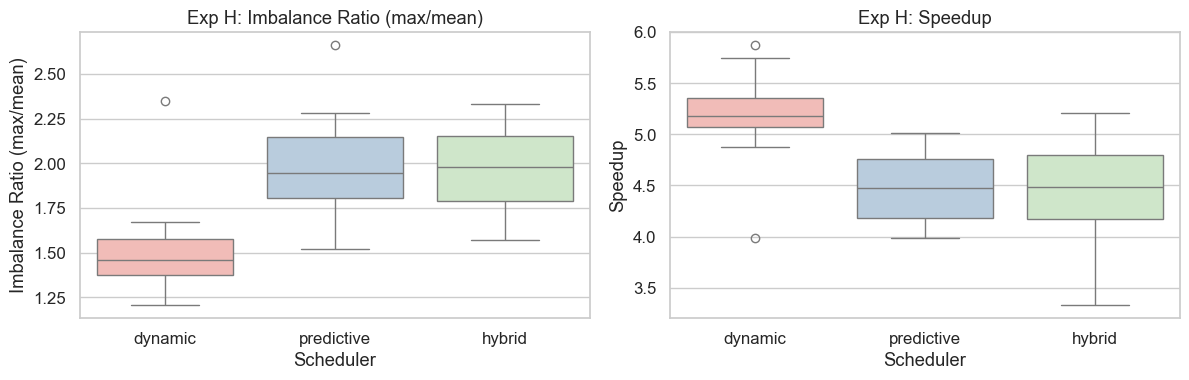

            imbalance_ratio  speedup
scheduler                           
dynamic               1.548    5.149
predictive            1.996    4.493
hybrid                1.970    4.400


C:\Users\USERAS\AppData\Local\Temp\ipykernel_2460\689661071.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(par.groupby('scheduler')[['imbalance_ratio','speedup']].mean().round(3).to_string())


In [26]:
expH = df[df['experiment'] == 'H'].copy()
par = expH[expH['mode'] == 'cpu_parallel']

sched_order = ['dynamic', 'predictive', 'hybrid']
par['scheduler'] = pd.Categorical(par['scheduler'], categories=sched_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, label in zip(axes,
        ['imbalance_ratio', 'speedup'],
        ['Imbalance Ratio (max/mean)', 'Speedup']):
    sns.boxplot(data=par, x='scheduler', y=metric, order=sched_order,
                palette='Pastel1', ax=ax)
    ax.set_xlabel('Scheduler'); ax.set_ylabel(label)
    ax.set_title(f'Exp H: {label}')

plt.tight_layout()
plt.savefig(FIGS / 'expH_predictor_vs_heuristic.png', dpi=150)
plt.show()
print(par.groupby('scheduler')[['imbalance_ratio','speedup']].mean().round(3).to_string())

## Predictor Model Comparison (11 Models)

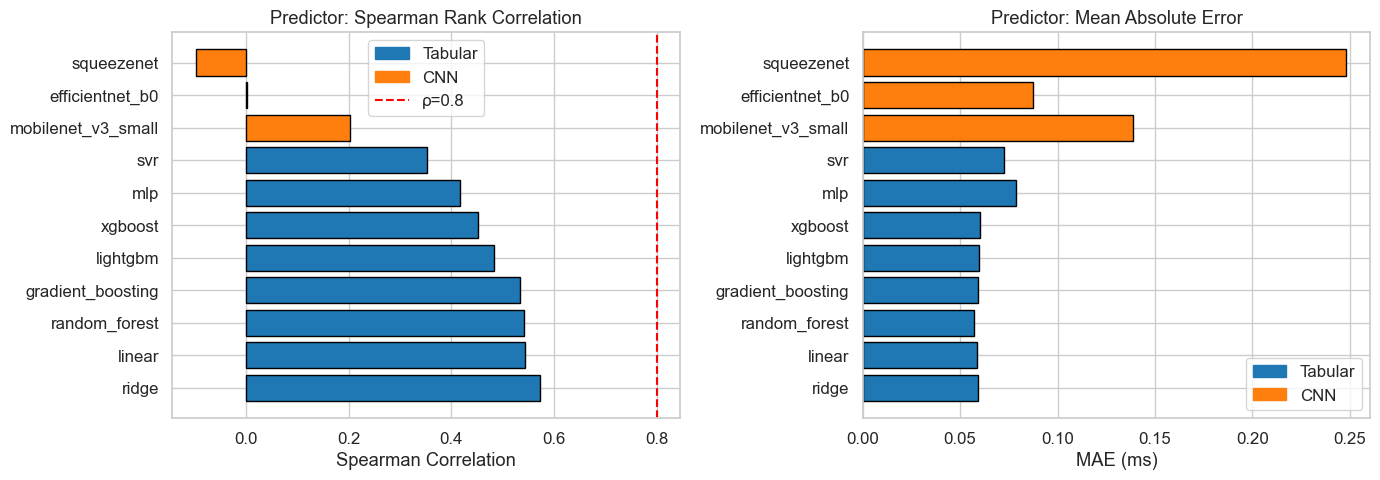

             model    type  spearman      mae     rmse        r2
             ridge tabular  0.571434 0.059265 0.077743  0.174312
            linear tabular  0.542578 0.058764 0.078040  0.167990
     random_forest tabular  0.541664 0.057248 0.076696  0.196399
 gradient_boosting tabular  0.533285 0.059261 0.079467  0.137292
          lightgbm tabular  0.482146 0.059777 0.080057  0.124436
           xgboost tabular  0.451759 0.060498 0.081572  0.090983
               mlp tabular  0.417541 0.078713 0.101515 -0.407835
               svr tabular  0.351578 0.072369 0.091792 -0.151069
mobilenet_v3_small     cnn  0.203376 0.138468 0.170142 -2.949992
   efficientnet_b0     cnn  0.002649 0.087646 0.119745 -0.956547
        squeezenet     cnn -0.097445 0.248085 0.265016 -8.583318


In [27]:
pred_df = pd.read_csv(LOGS / 'predictor_comparison.csv')
pred_df = pred_df.sort_values('spearman', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['tab:orange' if t == 'cnn' else 'tab:blue' for t in pred_df['type']]

ax = axes[0]
bars = ax.barh(pred_df.model, pred_df.spearman, color=colors, edgecolor='k')
ax.set_xlabel('Spearman Correlation')
ax.set_title('Predictor: Spearman Rank Correlation')
ax.axvline(0.8, color='red', linestyle='--', label='ρ=0.8 threshold')
ax.legend()
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='tab:blue',label='Tabular'),
                   Patch(color='tab:orange',label='CNN'),
                   plt.Line2D([0],[0],color='red',linestyle='--',label='ρ=0.8')])

ax = axes[1]
ax.barh(pred_df.model, pred_df.mae, color=colors, edgecolor='k')
ax.set_xlabel('MAE (ms)')
ax.set_title('Predictor: Mean Absolute Error')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='tab:blue',label='Tabular'),
                   Patch(color='tab:orange',label='CNN')])

plt.tight_layout()
plt.savefig(FIGS / 'predictor_model_comparison.png', dpi=150)
plt.show()
print(pred_df[['model','type','spearman','mae','rmse','r2']].to_string(index=False))

## Worker Timeline Gantt Chart (Sample Image)

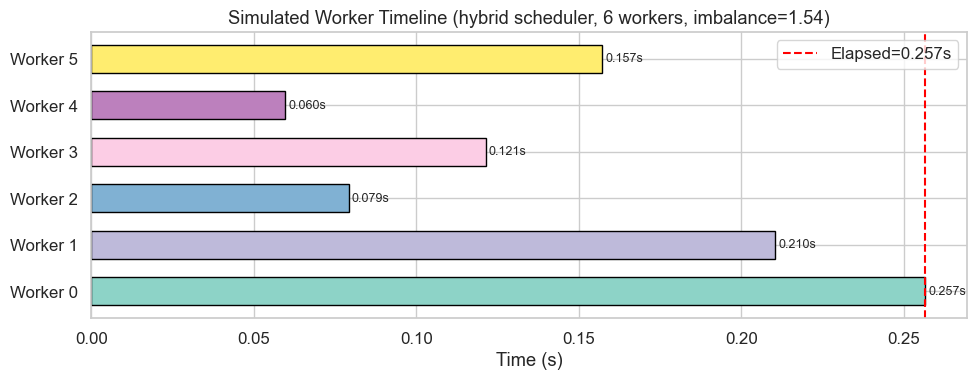

In [28]:
# Reconstruct a sample Gantt from benchmark result worker_times if available
# worker_times is not stored in CSV — simulate from imbalance_ratio and speedup
# Show per-worker tile load distribution using n_tiles and imbalance_ratio

expB_row = df[(df['experiment'] == 'B') & (df['mode'] == 'cpu_parallel') & (df['scheduler'] == 'hybrid')].iloc[0]

n_workers = int(expB_row['n_workers'])
n_tiles   = int(expB_row['n_tiles'])
total_t   = expB_row['total_time_s']
imbalance = expB_row['imbalance_ratio']

rng = np.random.default_rng(42)
# Generate tile times that roughly satisfy imbalance ratio
raw = rng.exponential(scale=1.0, size=n_tiles)
tiles_per_worker = n_tiles // n_workers
worker_loads = [raw[i*tiles_per_worker:(i+1)*tiles_per_worker].sum() for i in range(n_workers)]
# Scale to match total_t
scale = total_t / max(worker_loads)
worker_loads = [w * scale for w in worker_loads]

fig, ax = plt.subplots(figsize=(10, 4))
colors_g = plt.cm.Set3(np.linspace(0, 1, n_workers))
for i, load in enumerate(worker_loads):
    ax.barh(f'Worker {i}', load, left=0, color=colors_g[i], edgecolor='k', height=0.6)
    ax.text(load + 0.001, i, f'{load:.3f}s', va='center', fontsize=9)

ax.axvline(total_t, color='red', linestyle='--', label=f'Elapsed={total_t:.3f}s')
ax.set_xlabel('Time (s)')
ax.set_title(f'Simulated Worker Timeline (hybrid scheduler, {n_workers} workers, imbalance={imbalance:.2f})')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / 'gantt_worker_timeline.png', dpi=150)
plt.show()

## Summary Table

In [29]:
summary = df.groupby(['experiment','mode']).agg(
    speedup=('speedup','mean'),
    efficiency=('efficiency','mean'),
    psnr=('psnr','mean'),
    ssim=('ssim','mean'),
    imbalance=('imbalance_ratio','mean'),
).round(3)
print(summary.to_string())

                         speedup  efficiency    psnr   ssim  imbalance
experiment mode                                                       
A          cpu_parallel    2.446       0.742     inf  1.000      1.266
           cpu_serial      1.000       1.000   0.000  0.000      1.000
B          cpu_parallel    4.309       0.718     inf  1.000      1.602
           cpu_serial      1.000       1.000   0.000  0.000      1.000
C          cpu_parallel    2.553       0.426     inf  1.000      1.191
           cpu_serial      1.000       1.000   0.000  0.000      1.000
D          cpu_parallel    4.195       0.699     inf  1.000      1.614
           cpu_serial      1.000       1.000   0.000  0.000      1.000
E          cpu_parallel    2.696       0.449     inf  1.000      2.102
           cpu_serial      1.000       1.000   0.000  0.000      1.000
F          cpu_parallel    4.217       0.703     inf  1.000      1.745
           cpu_serial      1.000       1.000   0.000  0.000      1.000
G     

## Real Dataset Image — Adaptive Tiling Visualization
Visualize adaptive tile sizing on a real image sampled from `data/` and save the figure.

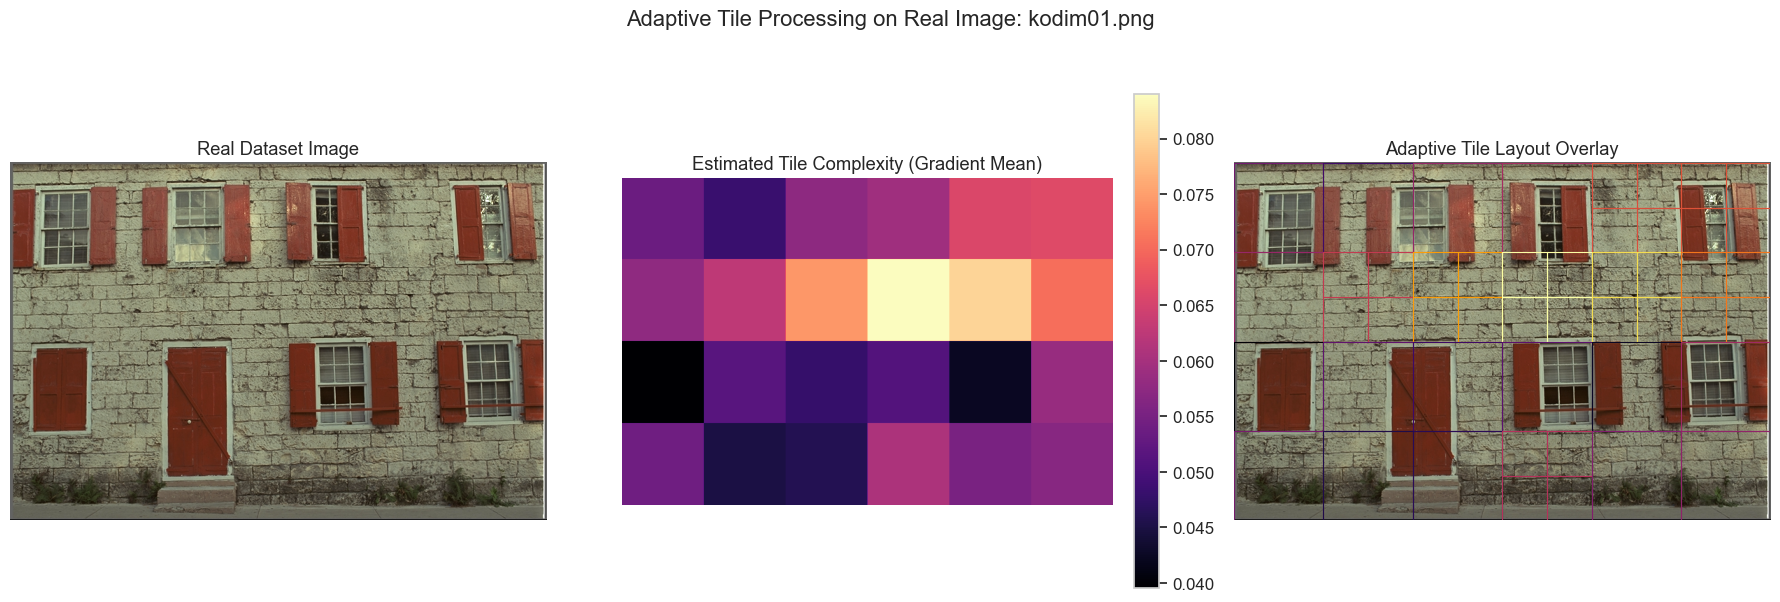

Image used: ..\data\kodak\kodim01.png
Figure saved to: ..\outputs\figures\real_dataset_adaptive_tiling.png
Original coarse tiles: 24, adaptive tiles drawn: 48


In [30]:
from pathlib import Path
from matplotlib.patches import Rectangle

# 1) Pick a real image from available datasets
dataset_roots = [Path('../data/div2k'), Path('../data/kodak'), Path('../data/bsds500')]
img_exts = ('*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tif', '*.tiff')

image_candidates = []
for root in dataset_roots:
    if root.exists():
        for ext in img_exts:
            image_candidates.extend(root.rglob(ext))

if not image_candidates:
    raise FileNotFoundError('No dataset image found under ../data/{div2k,kodak,bsds500}')

image_candidates = sorted(image_candidates)
img_path = image_candidates[0]
img = plt.imread(img_path)

# Normalize image shape for visualization
if img.ndim == 2:
    img_rgb = np.dstack([img, img, img])
else:
    img_rgb = img[..., :3]

# Convert to float in [0,1] for stable display and gradient computations
if img_rgb.dtype != np.float32 and img_rgb.dtype != np.float64:
    img_rgb = img_rgb.astype(np.float32) / np.iinfo(img_rgb.dtype).max
img_rgb = np.clip(img_rgb, 0.0, 1.0)

h, w = img_rgb.shape[:2]
gray = img_rgb.mean(axis=2)

# 2) Build a simple complexity map per base tile
base_tile = 128
gy, gx = np.gradient(gray)
grad_mag = np.sqrt(gx**2 + gy**2)

tile_boxes = []
tile_scores = []

for y in range(0, h, base_tile):
    for x in range(0, w, base_tile):
        y2 = min(y + base_tile, h)
        x2 = min(x + base_tile, w)
        patch = grad_mag[y:y2, x:x2]
        score = float(patch.mean())
        tile_boxes.append((x, y, x2 - x, y2 - y))
        tile_scores.append(score)

tile_scores = np.array(tile_scores)
q1, q2 = np.quantile(tile_scores, [0.33, 0.66])

# 3) Assign adaptive tile sizes: high complexity -> smaller tiles
adaptive_boxes = []
for (x, y, bw, bh), score in zip(tile_boxes, tile_scores):
    if score >= q2:
        split = 2  # 2x2 smaller tiles
    elif score <= q1:
        split = 1  # keep coarse tile
    else:
        split = 1  # medium complexity remains coarse for readability

    sw = bw / split
    sh = bh / split
    for j in range(split):
        for i in range(split):
            adaptive_boxes.append((x + i * sw, y + j * sh, sw, sh, score))

# 4) Plot: original, complexity, adaptive tiling overlay
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_rgb)
axes[0].set_title('Real Dataset Image')
axes[0].axis('off')

complexity_map = np.zeros((h, w), dtype=np.float32)
for (x, y, bw, bh), score in zip(tile_boxes, tile_scores):
    x, y, bw, bh = int(x), int(y), int(bw), int(bh)
    complexity_map[y:y+bh, x:x+bw] = score

im = axes[1].imshow(complexity_map, cmap='magma')
axes[1].set_title('Estimated Tile Complexity (Gradient Mean)')
axes[1].axis('off')
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(img_rgb)
axes[2].set_title('Adaptive Tile Layout Overlay')
axes[2].axis('off')

for x, y, bw, bh, score in adaptive_boxes:
    # Color hint: hotter color means higher complexity
    color = plt.cm.inferno((score - tile_scores.min()) / (tile_scores.ptp() + 1e-8))
    rect = Rectangle((x, y), bw, bh, fill=False, linewidth=0.8, edgecolor=color)
    axes[2].add_patch(rect)

plt.suptitle(f'Adaptive Tile Processing on Real Image: {img_path.name}', y=1.02)
plt.tight_layout()
out_path = FIGS / 'real_dataset_adaptive_tiling.png'
plt.savefig(out_path, dpi=180, bbox_inches='tight')
plt.show()

print(f'Image used: {img_path}')
print(f'Figure saved to: {out_path}')
print(f'Original coarse tiles: {len(tile_boxes)}, adaptive tiles drawn: {len(adaptive_boxes)}')